# Notebook 06 — Baseline Models and Experimental Protocol

## Objective

This notebook establishes the baseline predictive-model suite for the two
pre-match tasks.

### Model 1 — Pre-Match Outcome Classification

Input:

- one leakage-safe feature vector per fixture.

Output:

\[
P(A),\;P(D),\;P(H)
\]

for Away Win, Draw and Home Win.

Primary evaluation metric:

- Ranked Probability Score (RPS).

Additional metrics:

- Log-Loss;
- multiclass Brier Score;
- Expected Calibration Error (ECE);
- accuracy;
- balanced accuracy;
- macro F1.

### Model 2 — Pre-Match Goal-Margin Regression

Input:

- the same pre-match feature vector.

Output:

\[
\hat{y}
=
\widehat{
\operatorname{clip}
(
\text{home goals}
-
\text{away goals},
-5,
5
)
}.
\]

Evaluation metrics:

- MAE;
- RMSE;
- correlation with the observed margin.

---

## Baseline model families

The required baseline suite is:

### Classification

- Dummy class-prior model;
- RBF Kernel SVM;
- Random Forest;
- Gradient Boosting;
- XGBoost;
- LightGBM;
- de-vigged bookmaker probabilities as an external benchmark.

### Regression

- Dummy mean-margin model;
- RBF SVR;
- exact RBF Kernel Ridge Regression;
- approximate RBF kernel regression using Nystroem features;
- Random Forest;
- Gradient Boosting;
- XGBoost;
- LightGBM.

FIGS is deliberately excluded from this notebook and will be implemented in
Notebook 07.

---

## Evaluation protocol

The previously established chronological held-out test boundary is retained:

```text
Development period : before 2016-04-02
Held-out test      : 2016-04-02 onward

In [7]:
%pip install xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 685.5 kB/s eta 0:00:00m eta 0:00:010:00:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 663.5 kB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.0/461.0 kB 545.8 kB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 761.9 kB/s eta 0:00:00m eta 0:00:010:00:10
Note: you may need to restart the kernel to use updated packages.


In [2]:
# -------------------------------------------------------------------------
# STANDARD LIBRARY
# -------------------------------------------------------------------------

from pathlib import Path
from importlib.metadata import version
import json
import time
import warnings
import sys

# -------------------------------------------------------------------------
# CORE DATA LIBRARIES
# -------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# SCIKIT-LEARN
# -------------------------------------------------------------------------

import sklearn

from sklearn.base import clone

from sklearn.dummy import (
    DummyClassifier,
    DummyRegressor,
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit,
    ParameterGrid,
)

from sklearn.calibration import CalibratedClassifierCV

from sklearn.svm import (
    SVC,
    SVR,
)

from sklearn.kernel_ridge import KernelRidge
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
)

# -------------------------------------------------------------------------
# EXTERNAL BASELINE LIBRARIES
# -------------------------------------------------------------------------

from xgboost import (
    XGBClassifier,
    XGBRegressor,
)

from lightgbm import (
    LGBMClassifier,
    LGBMRegressor,
)

# -------------------------------------------------------------------------
# MODEL SERIALIZATION
# -------------------------------------------------------------------------

import joblib

# -------------------------------------------------------------------------
# DISPLAY SETTINGS
# -------------------------------------------------------------------------

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 220)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

# -------------------------------------------------------------------------
# REPRODUCIBILITY
# -------------------------------------------------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------------------------------------------------------
# ENVIRONMENT CHECK
# -------------------------------------------------------------------------

print("Notebook 06 environment configured.")
print(f"Python         : {sys.executable}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"xgboost       : {version('xgboost')}")
print(f"lightgbm      : {version('lightgbm')}")

Notebook 06 environment configured.
Python         : /home/sina/anaconda3/bin/python
scikit-learn  : 1.2.2
xgboost       : 3.2.0
lightgbm      : 4.7.0


In [3]:
# -------------------------------------------------------------------------
# EXTERNAL BASELINE LIBRARIES
# -------------------------------------------------------------------------

missing_packages = []

try:
    from xgboost import (
        XGBClassifier,
        XGBRegressor,
    )
except ImportError:
    missing_packages.append("xgboost")

try:
    from lightgbm import (
        LGBMClassifier,
        LGBMRegressor,
    )
except ImportError:
    missing_packages.append("lightgbm")


if missing_packages:
    raise ImportError(
        "Notebook 06 requires the following missing packages:\n"
        f"{missing_packages}\n\n"
        "Run this in a notebook cell:\n"
        "%pip install xgboost lightgbm\n"
        "Then restart the kernel and rerun the notebook."
    )

In [4]:
# -------------------------------------------------------------------------
# INPUT PATHS
# -------------------------------------------------------------------------

MODELING_DATASET_PATH = Path(
    "../data/processed/"
    "prematch_modeling_dataset_laliga_2015_2016.parquet"
)

FEATURE_MANIFEST_PATH = Path(
    "../data/processed/"
    "prematch_modeling_feature_manifest_laliga_2015_2016.csv"
)


# -------------------------------------------------------------------------
# OUTPUT DIRECTORIES
# -------------------------------------------------------------------------

BASELINE_MODEL_DIR = Path(
    "../models/baselines"
)

BASELINE_RESULTS_DIR = Path(
    "../data/processed/baseline_results"
)

BASELINE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -------------------------------------------------------------------------
# OUTPUT FILES
# -------------------------------------------------------------------------

EXPERIMENT_CONFIG_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_baseline_experiment_config.json"
)

CLASSIFICATION_CV_RESULTS_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_classification_model_selection.csv"
)

REGRESSION_CV_RESULTS_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_regression_model_selection.csv"
)

CALIBRATION_RESULTS_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_classification_calibration_results.csv"
)


# -------------------------------------------------------------------------
# INPUT VALIDATION
# -------------------------------------------------------------------------

for required_path in [
    MODELING_DATASET_PATH,
    FEATURE_MANIFEST_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            "Required Notebook 05 output not found:\n"
            f"{required_path.resolve()}"
        )


print("Notebook 06 paths configured.")
print(
    f"Modeling dataset : "
    f"{MODELING_DATASET_PATH.resolve()}"
)
print(
    f"Feature manifest : "
    f"{FEATURE_MANIFEST_PATH.resolve()}"
)
print(
    f"Model directory  : "
    f"{BASELINE_MODEL_DIR.resolve()}"
)

Notebook 06 paths configured.
Modeling dataset : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/prematch_modeling_dataset_laliga_2015_2016.parquet
Feature manifest : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/prematch_modeling_feature_manifest_laliga_2015_2016.csv
Model directory  : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/models/baselines


In [5]:
# -------------------------------------------------------------------------
# LOAD NOTEBOOK 05 OUTPUTS
# -------------------------------------------------------------------------

modeling_df = pd.read_parquet(
    MODELING_DATASET_PATH
)

feature_manifest_df = pd.read_csv(
    FEATURE_MANIFEST_PATH
)


modeling_df[
    "clean_date"
] = pd.to_datetime(
    modeling_df["clean_date"],
    errors="raise",
)


modeling_df = (
    modeling_df
    .sort_values(
        [
            "clean_date",
            "match_id",
        ]
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# BASIC STRUCTURAL VALIDATION
# -------------------------------------------------------------------------

assert len(modeling_df) == 380

assert modeling_df[
    "match_id"
].is_unique

assert modeling_df[
    "target_outcome"
].notna().all()

assert modeling_df[
    "target_margin"
].notna().all()


# -------------------------------------------------------------------------
# RECOVER FROZEN FEATURE FAMILIES FROM MANIFEST
# -------------------------------------------------------------------------

predictor_flag = (
    feature_manifest_df[
        "used_as_predictor"
    ]
)

if predictor_flag.dtype != bool:
    predictor_flag = (
        predictor_flag
        .astype(str)
        .str.lower()
        .eq("true")
    )


FULL_FEATURE_COLUMNS = (
    feature_manifest_df.loc[
        predictor_flag,
        "column",
    ]
    .tolist()
)


CONVENTIONAL_FEATURE_COLUMNS = (
    feature_manifest_df.loc[
        predictor_flag
        & feature_manifest_df[
            "feature_family"
        ].astype(str).str.lower().eq(
            "conventional"
        ),
        "column",
    ]
    .tolist()
)


NETWORK_FEATURE_COLUMNS = (
    feature_manifest_df.loc[
        predictor_flag
        & feature_manifest_df[
            "feature_family"
        ].astype(str).str.lower().eq(
            "network"
        ),
        "column",
    ]
    .tolist()
)


MARKET_PROBABILITY_COLUMNS = [
    "market_prob_A",
    "market_prob_D",
    "market_prob_H",
]


# -------------------------------------------------------------------------
# VALIDATE FEATURE FAMILIES
# -------------------------------------------------------------------------

assert len(
    FULL_FEATURE_COLUMNS
) == 186

assert len(
    CONVENTIONAL_FEATURE_COLUMNS
) == 6

assert len(
    NETWORK_FEATURE_COLUMNS
) == 180

assert set(
    FULL_FEATURE_COLUMNS
) == (
    set(
        CONVENTIONAL_FEATURE_COLUMNS
    )
    | set(
        NETWORK_FEATURE_COLUMNS
    )
)

assert all(
    column in modeling_df.columns
    for column
    in FULL_FEATURE_COLUMNS
)

assert all(
    column in modeling_df.columns
    for column
    in MARKET_PROBABILITY_COLUMNS
)


print("Notebook 05 dataset loaded and validated.")
print(
    f"Matches                 : "
    f"{len(modeling_df):,}"
)
print(
    f"Conventional predictors : "
    f"{len(CONVENTIONAL_FEATURE_COLUMNS):,}"
)
print(
    f"Network predictors      : "
    f"{len(NETWORK_FEATURE_COLUMNS):,}"
)
print(
    f"Combined predictors     : "
    f"{len(FULL_FEATURE_COLUMNS):,}"
)
print(
    f"Market probabilities    : "
    f"{len(MARKET_PROBABILITY_COLUMNS):,}"
)

Notebook 05 dataset loaded and validated.
Matches                 : 380
Conventional predictors : 6
Network predictors      : 180
Combined predictors     : 186
Market probabilities    : 3


In [6]:
# -------------------------------------------------------------------------
# ORDERED CLASSIFICATION TARGET
# -------------------------------------------------------------------------

CLASS_LABELS = [
    "A",
    "D",
    "H",
]

CLASS_TO_INT = {
    "A": 0,
    "D": 1,
    "H": 2,
}

INT_TO_CLASS = {
    value: key
    for key, value
    in CLASS_TO_INT.items()
}


assert set(
    modeling_df[
        "target_outcome"
    ].unique()
) == set(
    CLASS_LABELS
)


modeling_df[
    "target_outcome_int"
] = (
    modeling_df[
        "target_outcome"
    ]
    .map(
        CLASS_TO_INT
    )
    .astype("int8")
)


assert set(
    modeling_df[
        "target_outcome_int"
    ].unique()
) == {
    0,
    1,
    2,
}


print("Ordered classification target encoded.")
print(CLASS_TO_INT)

display(
    modeling_df[
        [
            "target_outcome",
            "target_outcome_int",
        ]
    ]
    .value_counts()
    .rename(
        "matches"
    )
    .reset_index()
)

Ordered classification target encoded.
{'A': 0, 'D': 1, 'H': 2}


,target_outcome,target_outcome_int,matches
0,H,2,183
1,A,0,105
2,D,1,92


In [7]:
# -------------------------------------------------------------------------
# FIXED HELD-OUT TEST BOUNDARY
# -------------------------------------------------------------------------

TEST_START_DATE = pd.Timestamp(
    "2016-04-02"
)


development_df = (
    modeling_df.loc[
        modeling_df[
            "clean_date"
        ] < TEST_START_DATE
    ]
    .copy()
    .reset_index(drop=True)
)


sealed_test_df = (
    modeling_df.loc[
        modeling_df[
            "clean_date"
        ] >= TEST_START_DATE
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    f"Development matches: {len(development_df):,}"
)
print(
    f"Sealed test matches: {len(sealed_test_df):,}"
)


assert (
    len(development_df)
    + len(sealed_test_df)
    == 380
)

assert (
    development_df[
        "clean_date"
    ].max()
    < sealed_test_df[
        "clean_date"
    ].min()
)


# -------------------------------------------------------------------------
# FINAL TEMPORAL CALIBRATION / VALIDATION BLOCK
# -------------------------------------------------------------------------

approx_calibration_index = int(
    np.floor(
        len(development_df)
        * 0.80
    )
)


CALIBRATION_START_DATE = (
    development_df.iloc[
        approx_calibration_index
    ][
        "clean_date"
    ]
)


training_df = (
    development_df.loc[
        development_df[
            "clean_date"
        ] < CALIBRATION_START_DATE
    ]
    .copy()
    .reset_index(drop=True)
)


calibration_df = (
    development_df.loc[
        development_df[
            "clean_date"
        ] >= CALIBRATION_START_DATE
    ]
    .copy()
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# TEMPORAL VALIDATION
# -------------------------------------------------------------------------

assert not training_df.empty
assert not calibration_df.empty
assert not sealed_test_df.empty

assert (
    training_df[
        "clean_date"
    ].max()
    < calibration_df[
        "clean_date"
    ].min()
)

assert (
    calibration_df[
        "clean_date"
    ].max()
    < sealed_test_df[
        "clean_date"
    ].min()
)


for partition_name, partition_df in [
    (
        "training",
        training_df,
    ),
    (
        "calibration",
        calibration_df,
    ),
    (
        "test",
        sealed_test_df,
    ),
]:
    assert set(
        partition_df[
            "target_outcome_int"
        ].unique()
    ) == {
        0,
        1,
        2,
    }, (
        f"{partition_name} partition "
        "does not contain all classes."
    )


print("\nChronological experiment partitions frozen.")

print(
    f"Training / model selection : "
    f"{len(training_df):,} matches | "
    f"{training_df['clean_date'].min().date()} "
    f"to "
    f"{training_df['clean_date'].max().date()}"
)

print(
    f"Calibration / validation  : "
    f"{len(calibration_df):,} matches | "
    f"{calibration_df['clean_date'].min().date()} "
    f"to "
    f"{calibration_df['clean_date'].max().date()}"
)

print(
    f"SEALED test               : "
    f"{len(sealed_test_df):,} matches | "
    f"{sealed_test_df['clean_date'].min().date()} "
    f"to "
    f"{sealed_test_df['clean_date'].max().date()}"
)

Development matches: 301
Sealed test matches: 79

Chronological experiment partitions frozen.
Training / model selection : 240 matches | 2015-08-21 to 2016-02-17
Calibration / validation  : 61 matches | 2016-02-19 to 2016-04-01
SEALED test               : 79 matches | 2016-04-02 to 2016-05-15


In [8]:
# -------------------------------------------------------------------------
# MODEL-SELECTION MATRICES
# -------------------------------------------------------------------------

X_train = (
    training_df[
        FULL_FEATURE_COLUMNS
    ]
    .copy()
)

y_class_train = (
    training_df[
        "target_outcome_int"
    ]
    .to_numpy()
)

y_margin_train = (
    training_df[
        "target_margin"
    ]
    .to_numpy(
        dtype=float
    )
)


# -------------------------------------------------------------------------
# CALIBRATION / VALIDATION MATRICES
# -------------------------------------------------------------------------

X_calibration = (
    calibration_df[
        FULL_FEATURE_COLUMNS
    ]
    .copy()
)

y_class_calibration = (
    calibration_df[
        "target_outcome_int"
    ]
    .to_numpy()
)

y_margin_calibration = (
    calibration_df[
        "target_margin"
    ]
    .to_numpy(
        dtype=float
    )
)


market_calibration_proba = (
    calibration_df[
        MARKET_PROBABILITY_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)


# -------------------------------------------------------------------------
# TEST SET REMAINS SEALED
# -------------------------------------------------------------------------

sealed_test_identity_df = (
    sealed_test_df[
        [
            "match_id",
            "clean_date",
            "home_team",
            "away_team",
        ]
    ]
    .copy()
)


# Deliberately do not create:
#
# X_test
# y_class_test
# y_margin_test
#
# Those will first appear in Notebook 07.


assert X_train.shape[
    1
] == 186

assert X_calibration.shape[
    1
] == 186


print("Training and calibration matrices materialized.")
print(
    f"X_train       : "
    f"{X_train.shape}"
)
print(
    f"X_calibration : "
    f"{X_calibration.shape}"
)
print(
    "Held-out test predictors/labels remain sealed."
)

Training and calibration matrices materialized.
X_train       : (240, 186)
X_calibration : (61, 186)
Held-out test predictors/labels remain sealed.


In [9]:
# -------------------------------------------------------------------------
# DATE-BLOCKED EXPANDING CROSS-VALIDATION
# -------------------------------------------------------------------------

N_TEMPORAL_CV_SPLITS = 4


unique_training_dates = np.array(
    sorted(
        training_df[
            "clean_date"
        ].unique()
    )
)


date_splitter = TimeSeriesSplit(
    n_splits=N_TEMPORAL_CV_SPLITS
)


TEMPORAL_CV_SPLITS = []
cv_summary_records = []


for fold_number, (
    train_date_indices,
    validation_date_indices,
) in enumerate(
    date_splitter.split(
        unique_training_dates
    ),
    start=1,
):

    fold_train_dates = (
        unique_training_dates[
            train_date_indices
        ]
    )

    fold_validation_dates = (
        unique_training_dates[
            validation_date_indices
        ]
    )


    fold_train_indices = np.flatnonzero(
        training_df[
            "clean_date"
        ].isin(
            fold_train_dates
        )
        .to_numpy()
    )

    fold_validation_indices = np.flatnonzero(
        training_df[
            "clean_date"
        ].isin(
            fold_validation_dates
        )
        .to_numpy()
    )


    assert (
        training_df.iloc[
            fold_train_indices
        ][
            "clean_date"
        ].max()
        <
        training_df.iloc[
            fold_validation_indices
        ][
            "clean_date"
        ].min()
    )


    TEMPORAL_CV_SPLITS.append(
        (
            fold_train_indices,
            fold_validation_indices,
        )
    )


    cv_summary_records.append(
        {
            "fold": fold_number,
            "train_matches": (
                len(
                    fold_train_indices
                )
            ),
            "validation_matches": (
                len(
                    fold_validation_indices
                )
            ),
            "train_start": (
                training_df.iloc[
                    fold_train_indices
                ][
                    "clean_date"
                ].min()
            ),
            "train_end": (
                training_df.iloc[
                    fold_train_indices
                ][
                    "clean_date"
                ].max()
            ),
            "validation_start": (
                training_df.iloc[
                    fold_validation_indices
                ][
                    "clean_date"
                ].min()
            ),
            "validation_end": (
                training_df.iloc[
                    fold_validation_indices
                ][
                    "clean_date"
                ].max()
            ),
        }
    )


cv_summary_df = pd.DataFrame(
    cv_summary_records
)


assert len(
    TEMPORAL_CV_SPLITS
) == N_TEMPORAL_CV_SPLITS


print(
    "Date-blocked expanding temporal CV constructed."
)

display(
    cv_summary_df
)

Date-blocked expanding temporal CV constructed.


,fold,train_matches,validation_matches,train_start,train_end,validation_start,validation_end
0,1,43,47,2015-08-21,2015-09-22,2015-09-23,2015-10-26
1,2,90,50,2015-08-21,2015-10-26,2015-10-30,2015-12-07
2,3,140,59,2015-08-21,2015-12-07,2015-12-11,2016-01-18
3,4,199,41,2015-08-21,2016-01-18,2016-01-22,2016-02-17


In [10]:
# -------------------------------------------------------------------------
# PROBABILITY ALIGNMENT
# -------------------------------------------------------------------------

N_CLASSES = 3


def align_class_probabilities(
    probabilities,
    estimator_classes,
):
    """
    Align arbitrary estimator class order to:

        0 = Away
        1 = Draw
        2 = Home
    """

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    estimator_classes = np.asarray(
        estimator_classes,
        dtype=int,
    )


    aligned = np.zeros(
        (
            probabilities.shape[0],
            N_CLASSES,
        ),
        dtype=float,
    )


    for source_index, class_value in enumerate(
        estimator_classes
    ):
        aligned[
            :,
            int(class_value),
        ] = probabilities[
            :,
            source_index,
        ]


    return aligned


# -------------------------------------------------------------------------
# ONE-HOT TARGET
# -------------------------------------------------------------------------

def one_hot_classes(
    y_true,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    return np.eye(
        N_CLASSES,
        dtype=float,
    )[
        y_true
    ]


# -------------------------------------------------------------------------
# RANKED PROBABILITY SCORE
# -------------------------------------------------------------------------

def ranked_probability_score(
    y_true,
    probabilities,
):
    """
    Multiclass RPS for the ordered outcome:

        Away < Draw < Home

    Lower is better.
    """

    y_one_hot = one_hot_classes(
        y_true
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )


    assert probabilities.shape == (
        len(y_true),
        N_CLASSES,
    )


    probability_cdf = np.cumsum(
        probabilities,
        axis=1,
    )[
        :,
        :-1,
    ]

    observation_cdf = np.cumsum(
        y_one_hot,
        axis=1,
    )[
        :,
        :-1,
    ]


    return float(
        np.mean(
            np.sum(
                (
                    probability_cdf
                    - observation_cdf
                )
                ** 2,
                axis=1,
            )
            / (
                N_CLASSES - 1
            )
        )
    )


# -------------------------------------------------------------------------
# MULTICLASS BRIER SCORE
# -------------------------------------------------------------------------

def multiclass_brier_score(
    y_true,
    probabilities,
):
    y_one_hot = one_hot_classes(
        y_true
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - y_one_hot
                )
                ** 2,
                axis=1,
            )
        )
    )


# -------------------------------------------------------------------------
# TOP-LABEL EXPECTED CALIBRATION ERROR
# -------------------------------------------------------------------------

def expected_calibration_error(
    y_true,
    probabilities,
    n_bins=10,
):
    """
    Multiclass top-label ECE.

    Confidence = maximum predicted probability.
    Accuracy   = whether the most probable class was correct.
    """

    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )


    predicted_class = np.argmax(
        probabilities,
        axis=1,
    )

    confidence = np.max(
        probabilities,
        axis=1,
    )

    correct = (
        predicted_class
        == y_true
    ).astype(float)


    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )


    ece = 0.0


    for lower, upper in zip(
        bin_edges[:-1],
        bin_edges[1:],
    ):

        if upper == 1.0:
            bin_mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            bin_mask = (
                (confidence >= lower)
                & (confidence < upper)
            )


        if not np.any(
            bin_mask
        ):
            continue


        bin_weight = np.mean(
            bin_mask
        )

        bin_accuracy = np.mean(
            correct[
                bin_mask
            ]
        )

        bin_confidence = np.mean(
            confidence[
                bin_mask
            ]
        )


        ece += (
            bin_weight
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )


    return float(
        ece
    )


# -------------------------------------------------------------------------
# CLASSIFICATION METRIC BUNDLE
# -------------------------------------------------------------------------

def evaluate_classification_probabilities(
    y_true,
    probabilities,
):
    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )


    return {
        "rps": ranked_probability_score(
            y_true,
            probabilities,
        ),
        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[
                0,
                1,
                2,
            ],
        ),
        "brier": multiclass_brier_score(
            y_true,
            probabilities,
        ),
        "ece": expected_calibration_error(
            y_true,
            probabilities,
            n_bins=10,
        ),
        "accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                predictions,
            )
        ),
        "macro_f1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }


# -------------------------------------------------------------------------
# REGRESSION METRIC BUNDLE
# -------------------------------------------------------------------------

def evaluate_regression_predictions(
    y_true,
    predictions,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predictions = np.asarray(
        predictions,
        dtype=float,
    )


    if (
        np.std(
            predictions
        )
        == 0
        or np.std(
            y_true
        )
        == 0
    ):
        correlation = np.nan
    else:
        correlation = float(
            np.corrcoef(
                y_true,
                predictions,
            )[
                0,
                1,
            ]
        )


    return {
        "mae": mean_absolute_error(
            y_true,
            predictions,
        ),
        "rmse": np.sqrt(
            mean_squared_error(
                y_true,
                predictions,
            )
        ),
        "correlation": correlation,
    }


# -------------------------------------------------------------------------
# GRID-SEARCH RPS SCORER
# -------------------------------------------------------------------------

def negative_rps_scorer(
    estimator,
    X,
    y,
):
    raw_proba = estimator.predict_proba(
        X
    )

    aligned_proba = (
        align_class_probabilities(
            raw_proba,
            estimator.classes_,
        )
    )

    return -ranked_probability_score(
        y,
        aligned_proba,
    )


print("Evaluation metrics configured.")

Evaluation metrics configured.


In [11]:
# -------------------------------------------------------------------------
# COMMON IMPUTER
# -------------------------------------------------------------------------

def make_imputer():
    return SimpleImputer(
        strategy="median",
        keep_empty_features=True,
    )


# -------------------------------------------------------------------------
# SCALE-SENSITIVE PIPELINE
# -------------------------------------------------------------------------

def make_scaled_pipeline(
    estimator,
):
    return Pipeline(
        steps=[
            (
                "imputer",
                make_imputer(),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                estimator,
            ),
        ]
    )


# -------------------------------------------------------------------------
# TREE PIPELINE
# -------------------------------------------------------------------------

def make_tree_pipeline(
    estimator,
):
    return Pipeline(
        steps=[
            (
                "imputer",
                make_imputer(),
            ),
            (
                "model",
                estimator,
            ),
        ]
    )


print("Training-only preprocessing factories configured.")

Training-only preprocessing factories configured.


In [12]:
# -------------------------------------------------------------------------
# FAIR SEARCH BUDGET
# -------------------------------------------------------------------------

SEARCH_BUDGET = 8


# -------------------------------------------------------------------------
# CLASSIFICATION BASELINES
# -------------------------------------------------------------------------

classification_specs = {}


# -------------------------------------------------------------------------
# 1. RBF SVC
# -------------------------------------------------------------------------

classification_specs[
    "SVC_RBF"
] = {
    "estimator": make_scaled_pipeline(
        SVC(
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE,
        )
    ),
    "param_grid": {
        "model__C": [
            0.25,
            1.0,
            4.0,
            16.0,
        ],
        "model__gamma": [
            "scale",
            0.1,
        ],
    },
}


# -------------------------------------------------------------------------
# 2. RANDOM FOREST
# -------------------------------------------------------------------------

classification_specs[
    "RandomForest"
] = {
    "estimator": make_tree_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
    "param_grid": {
        "model__max_depth": [
            4,
            None,
        ],
        "model__min_samples_leaf": [
            1,
            5,
        ],
        "model__max_features": [
            "sqrt",
            0.5,
        ],
    },
}


# -------------------------------------------------------------------------
# 3. SKLEARN GRADIENT BOOSTING
# -------------------------------------------------------------------------

classification_specs[
    "GradientBoosting"
] = {
    "estimator": make_tree_pipeline(
        GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        )
    ),
    "param_grid": {
        "model__n_estimators": [
            100,
            200,
        ],
        "model__learning_rate": [
            0.03,
            0.08,
        ],
        "model__max_depth": [
            1,
            2,
        ],
    },
}


# -------------------------------------------------------------------------
# 4. XGBOOST
# -------------------------------------------------------------------------

classification_specs[
    "XGBoost"
] = {
    "estimator": make_tree_pipeline(
        XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            n_estimators=250,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
        )
    ),
    "param_grid": {
        "model__max_depth": [
            2,
            4,
        ],
        "model__learning_rate": [
            0.03,
            0.08,
        ],
        "model__subsample": [
            0.8,
            1.0,
        ],
    },
}


# -------------------------------------------------------------------------
# 5. LIGHTGBM
# -------------------------------------------------------------------------

classification_specs[
    "LightGBM"
] = {
    "estimator": make_tree_pipeline(
        LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
        )
    ),
    "param_grid": {
        "model__num_leaves": [
            7,
            15,
        ],
        "model__learning_rate": [
            0.03,
            0.08,
        ],
        "model__colsample_bytree": [
            0.8,
            1.0,
        ],
    },
}


# -------------------------------------------------------------------------
# SEARCH-BUDGET VALIDATION
# -------------------------------------------------------------------------

classification_search_budget_df = pd.DataFrame(
    [
        {
            "model": model_name,
            "configurations": len(
                list(
                    ParameterGrid(
                        spec[
                            "param_grid"
                        ]
                    )
                )
            ),
        }
        for model_name, spec
        in classification_specs.items()
    ]
)


assert classification_search_budget_df[
    "configurations"
].eq(
    SEARCH_BUDGET
).all()


print(
    "Classification baseline registry configured."
)

display(
    classification_search_budget_df
)

Classification baseline registry configured.


,model,configurations
0,SVC_RBF,8
1,RandomForest,8
2,GradientBoosting,8
3,XGBoost,8
4,LightGBM,8


In [13]:
# -------------------------------------------------------------------------
# REGRESSION BASELINES
# -------------------------------------------------------------------------

regression_specs = {}


# -------------------------------------------------------------------------
# 1. RBF SVR
# -------------------------------------------------------------------------

regression_specs[
    "SVR_RBF"
] = {
    "estimator": make_scaled_pipeline(
        SVR(
            kernel="rbf",
            epsilon=0.1,
        )
    ),
    "param_grid": {
        "model__C": [
            0.25,
            1.0,
            4.0,
            16.0,
        ],
        "model__gamma": [
            "scale",
            0.1,
        ],
    },
}


# -------------------------------------------------------------------------
# 2. EXACT RBF KERNEL RIDGE
# -------------------------------------------------------------------------

regression_specs[
    "KernelRidge_RBF"
] = {
    "estimator": make_scaled_pipeline(
        KernelRidge(
            kernel="rbf",
        )
    ),
    "param_grid": {
        "model__alpha": [
            0.01,
            0.1,
            1.0,
            10.0,
        ],
        "model__gamma": [
            0.01,
            0.1,
        ],
    },
}


# -------------------------------------------------------------------------
# 3. APPROXIMATE RBF KERNEL
# -------------------------------------------------------------------------

regression_specs[
    "Nystroem_Ridge"
] = {
    "estimator": Pipeline(
        steps=[
            (
                "imputer",
                make_imputer(),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "kernel",
                Nystroem(
                    kernel="rbf",
                    random_state=RANDOM_STATE,
                ),
            ),
            (
                "model",
                Ridge(),
            ),
        ]
    ),
    "param_grid": {
        "kernel__gamma": [
            0.01,
            0.1,
        ],
        "kernel__n_components": [
            25,
            50,
        ],
        "model__alpha": [
            0.1,
            1.0,
        ],
    },
}


# -------------------------------------------------------------------------
# 4. RANDOM FOREST
# -------------------------------------------------------------------------

regression_specs[
    "RandomForest"
] = {
    "estimator": make_tree_pipeline(
        RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
    "param_grid": {
        "model__max_depth": [
            4,
            None,
        ],
        "model__min_samples_leaf": [
            1,
            5,
        ],
        "model__max_features": [
            "sqrt",
            0.5,
        ],
    },
}


# -------------------------------------------------------------------------
# 5. SKLEARN GRADIENT BOOSTING
# -------------------------------------------------------------------------

regression_specs[
    "GradientBoosting"
] = {
    "estimator": make_tree_pipeline(
        GradientBoostingRegressor(
            random_state=RANDOM_STATE,
        )
    ),
    "param_grid": {
        "model__n_estimators": [
            100,
            200,
        ],
        "model__learning_rate": [
            0.03,
            0.08,
        ],
        "model__max_depth": [
            1,
            2,
        ],
    },
}


# -------------------------------------------------------------------------
# 6. XGBOOST
# -------------------------------------------------------------------------

regression_specs[
    "XGBoost"
] = {
    "estimator": make_tree_pipeline(
        XGBRegressor(
            objective="reg:squarederror",
            n_estimators=250,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
        )
    ),
    "param_grid": {
        "model__max_depth": [
            2,
            4,
        ],
        "model__learning_rate": [
            0.03,
            0.08,
        ],
        "model__subsample": [
            0.8,
            1.0,
        ],
    },
}


# -------------------------------------------------------------------------
# 7. LIGHTGBM
# -------------------------------------------------------------------------

regression_specs[
    "LightGBM"
] = {
    "estimator": make_tree_pipeline(
        LGBMRegressor(
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
        )
    ),
    "param_grid": {
        "model__num_leaves": [
            7,
            15,
        ],
        "model__learning_rate": [
            0.03,
            0.08,
        ],
        "model__colsample_bytree": [
            0.8,
            1.0,
        ],
    },
}


# -------------------------------------------------------------------------
# SEARCH-BUDGET VALIDATION
# -------------------------------------------------------------------------

regression_search_budget_df = pd.DataFrame(
    [
        {
            "model": model_name,
            "configurations": len(
                list(
                    ParameterGrid(
                        spec[
                            "param_grid"
                        ]
                    )
                )
            ),
        }
        for model_name, spec
        in regression_specs.items()
    ]
)


assert regression_search_budget_df[
    "configurations"
].eq(
    SEARCH_BUDGET
).all()


print(
    "Regression baseline registry configured."
)

display(
    regression_search_budget_df
)

Regression baseline registry configured.


,model,configurations
0,SVR_RBF,8
1,KernelRidge_RBF,8
2,Nystroem_Ridge,8
3,RandomForest,8
4,GradientBoosting,8
5,XGBoost,8
6,LightGBM,8


In [14]:
# -------------------------------------------------------------------------
# GENERIC TEMPORAL GRID SEARCH
# -------------------------------------------------------------------------

def run_temporal_grid_search(
    model_name,
    estimator,
    param_grid,
    X,
    y,
    scoring,
):
    """
    Run leakage-safe hyperparameter selection using the frozen
    date-blocked expanding folds.
    """

    configuration_count = len(
        list(
            ParameterGrid(
                param_grid
            )
        )
    )

    assert (
        configuration_count
        == SEARCH_BUDGET
    )


    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=TEMPORAL_CV_SPLITS,
        refit=True,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )


    start_time = time.perf_counter()

    search.fit(
        X,
        y,
    )

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )


    result = {
        "model": model_name,
        "search_configurations": (
            configuration_count
        ),
        "best_cv_score": (
            float(
                search.best_score_
            )
        ),
        "best_params": (
            search.best_params_
        ),
        "fit_seconds": (
            float(
                elapsed_seconds
            )
        ),
        "best_estimator": (
            search.best_estimator_
        ),
        "search_object": search,
    }


    return result


print("Temporal grid-search helper configured.")

Temporal grid-search helper configured.


In [15]:
# -------------------------------------------------------------------------
# FROZEN EXPERIMENT CONFIGURATION
# -------------------------------------------------------------------------

experiment_config = {
    "random_state": RANDOM_STATE,
    "test_start_date": (
        TEST_START_DATE.strftime(
            "%Y-%m-%d"
        )
    ),
    "calibration_start_date": (
        pd.Timestamp(
            CALIBRATION_START_DATE
        ).strftime(
            "%Y-%m-%d"
        )
    ),
    "training_matches": int(
        len(
            training_df
        )
    ),
    "calibration_matches": int(
        len(
            calibration_df
        )
    ),
    "sealed_test_matches": int(
        len(
            sealed_test_df
        )
    ),
    "temporal_cv_splits": (
        N_TEMPORAL_CV_SPLITS
    ),
    "search_budget_per_model": (
        SEARCH_BUDGET
    ),
    "classification_class_order": (
        CLASS_LABELS
    ),
    "feature_count": int(
        len(
            FULL_FEATURE_COLUMNS
        )
    ),
    "conventional_feature_count": int(
        len(
            CONVENTIONAL_FEATURE_COLUMNS
        )
    ),
    "network_feature_count": int(
        len(
            NETWORK_FEATURE_COLUMNS
        )
    ),
    "test_set_opened": False,
}


with open(
    EXPERIMENT_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        experiment_config,
        file_handle,
        indent=4,
    )


print(
    "Frozen experiment configuration saved."
)

display(
    pd.Series(
        experiment_config,
        name="value",
    )
    .to_frame()
)

Frozen experiment configuration saved.


,value
random_state,42
test_start_date,2016-04-02
calibration_start_date,2016-02-19
training_matches,240
calibration_matches,61
sealed_test_matches,79
temporal_cv_splits,4
search_budget_per_model,8
classification_class_order,"[A, D, H]"
feature_count,186


In [16]:
# -------------------------------------------------------------------------
# REMAINING NOTEBOOK 06 OUTPUT PATHS
# -------------------------------------------------------------------------

REGRESSION_CALIBRATION_RESULTS_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_regression_calibration_results.csv"
)

CLASSIFICATION_CALIBRATION_PREDICTIONS_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_classification_calibration_predictions.csv"
)

REGRESSION_CALIBRATION_PREDICTIONS_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_regression_calibration_predictions.csv"
)

BASELINE_SELECTION_PATH = (
    BASELINE_RESULTS_DIR
    / "prematch_baseline_model_selection.json"
)


print("Remaining Notebook 06 output paths configured.")

Remaining Notebook 06 output paths configured.


In [17]:
# -------------------------------------------------------------------------
# FINAL PRE-FIT SAFETY CHECK
# -------------------------------------------------------------------------

assert X_train.shape == (
    len(training_df),
    186,
)

assert X_calibration.shape == (
    len(calibration_df),
    186,
)

assert len(y_class_train) == len(
    training_df
)

assert len(y_margin_train) == len(
    training_df
)

assert len(y_class_calibration) == len(
    calibration_df
)

assert len(y_margin_calibration) == len(
    calibration_df
)


# -------------------------------------------------------------------------
# MARKET PROBABILITIES
# -------------------------------------------------------------------------

assert market_calibration_proba.shape == (
    len(calibration_df),
    3,
)

assert np.all(
    market_calibration_proba >= 0
)

assert np.all(
    market_calibration_proba <= 1
)

assert np.allclose(
    market_calibration_proba.sum(
        axis=1
    ),
    1.0,
    atol=1e-6,
)


# -------------------------------------------------------------------------
# TEST SET MUST STILL BE SEALED
# -------------------------------------------------------------------------

assert "X_test" not in globals()
assert "y_class_test" not in globals()
assert "y_margin_test" not in globals()


print("Pre-fit safety validation passed.")
print(
    f"Training matches    : {len(training_df):,}"
)
print(
    f"Validation matches  : {len(calibration_df):,}"
)
print(
    f"Sealed test matches : {len(sealed_test_df):,}"
)

Pre-fit safety validation passed.
Training matches    : 240
Validation matches  : 61
Sealed test matches : 79


In [18]:
# -------------------------------------------------------------------------
# CLASSIFICATION TEMPORAL MODEL SELECTION
# -------------------------------------------------------------------------

classification_search_results = {}
classification_best_estimators = {}
classification_cv_records = []


for model_name, specification in (
    classification_specs.items()
):

    print(
        "\n"
        + "=" * 72
    )
    print(
        f"Classification search: {model_name}"
    )
    print(
        "=" * 72
    )


    result = run_temporal_grid_search(
        model_name=model_name,
        estimator=specification[
            "estimator"
        ],
        param_grid=specification[
            "param_grid"
        ],
        X=X_train,
        y=y_class_train,
        scoring=negative_rps_scorer,
    )


    classification_search_results[
        model_name
    ] = result

    classification_best_estimators[
        model_name
    ] = result[
        "best_estimator"
    ]


    search_object = result[
        "search_object"
    ]

    best_index = (
        search_object.best_index_
    )

    best_cv_rps = -float(
        search_object.best_score_
    )

    cv_rps_std = float(
        search_object.cv_results_[
            "std_test_score"
        ][
            best_index
        ]
    )


    classification_cv_records.append(
        {
            "model": model_name,
            "search_configurations": (
                result[
                    "search_configurations"
                ]
            ),
            "cv_mean_rps": best_cv_rps,
            "cv_std_rps": cv_rps_std,
            "fit_seconds": result[
                "fit_seconds"
            ],
            "best_params": json.dumps(
                result[
                    "best_params"
                ],
                sort_keys=True,
            ),
        }
    )


    model_output_path = (
        BASELINE_MODEL_DIR
        / (
            "classification_"
            f"{model_name.lower()}_"
            "selection_fit.joblib"
        )
    )


    joblib.dump(
        result[
            "best_estimator"
        ],
        model_output_path,
    )


    print(
        f"Best temporal-CV RPS: "
        f"{best_cv_rps:.4f}"
    )

    print(
        "Best parameters:"
    )

    print(
        result[
            "best_params"
        ]
    )


classification_cv_results_df = (
    pd.DataFrame(
        classification_cv_records
    )
    .sort_values(
        "cv_mean_rps",
        ascending=True,
    )
    .reset_index(drop=True)
)


classification_cv_results_df.to_csv(
    CLASSIFICATION_CV_RESULTS_PATH,
    index=False,
)


print(
    "\nClassification temporal model selection complete."
)

display(
    classification_cv_results_df
)


Classification search: SVC_RBF
Best temporal-CV RPS: 0.2202
Best parameters:
{'model__C': 0.25, 'model__gamma': 0.1}

Classification search: RandomForest
Best temporal-CV RPS: 0.2061
Best parameters:
{'model__max_depth': 4, 'model__max_features': 0.5, 'model__min_samples_leaf': 5}

Classification search: GradientBoosting
Best temporal-CV RPS: 0.2049
Best parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 1, 'model__n_estimators': 100}

Classification search: XGBoost
Best temporal-CV RPS: 0.2307
Best parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__subsample': 0.8}

Classification search: LightGBM
Best temporal-CV RPS: 0.2459
Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__num_leaves': 15}

Classification temporal model selection complete.


,model,search_configurations,cv_mean_rps,cv_std_rps,fit_seconds,best_params
0,GradientBoosting,8,0.2049,0.0153,5.1009,"{""model__learning_rate"": 0.03, ""model__max_dep..."
1,RandomForest,8,0.2061,0.0160,3.5688,"{""model__max_depth"": 4, ""model__max_features"":..."
2,SVC_RBF,8,0.2202,0.0073,1.6149,"{""model__C"": 0.25, ""model__gamma"": 0.1}"
3,XGBoost,8,0.2307,0.0255,6.1130,"{""model__learning_rate"": 0.03, ""model__max_dep..."
4,LightGBM,8,0.2459,0.0077,1.3987,"{""model__colsample_bytree"": 1.0, ""model__learn..."


In [19]:
# -------------------------------------------------------------------------
# CLASSIFICATION VALIDATION EVALUATION
# -------------------------------------------------------------------------

classification_calibration_records = []

classification_probability_store = {}


# -------------------------------------------------------------------------
# 1. DUMMY CLASS-PRIOR BASELINE
# -------------------------------------------------------------------------

dummy_classifier = DummyClassifier(
    strategy="prior"
)

dummy_X_train = np.zeros(
    (
        len(y_class_train),
        1,
    )
)

dummy_X_calibration = np.zeros(
    (
        len(y_class_calibration),
        1,
    )
)


dummy_classifier.fit(
    dummy_X_train,
    y_class_train,
)


dummy_proba = (
    align_class_probabilities(
        dummy_classifier.predict_proba(
            dummy_X_calibration
        ),
        dummy_classifier.classes_,
    )
)


classification_probability_store[
    "DummyPrior"
] = dummy_proba


dummy_metrics = (
    evaluate_classification_probabilities(
        y_class_calibration,
        dummy_proba,
    )
)


classification_calibration_records.append(
    {
        "model": "DummyPrior",
        "model_type": "reference",
        **dummy_metrics,
    }
)


# -------------------------------------------------------------------------
# 2. MARKET BENCHMARK
# -------------------------------------------------------------------------

classification_probability_store[
    "Market"
] = (
    market_calibration_proba
)


market_metrics = (
    evaluate_classification_probabilities(
        y_class_calibration,
        market_calibration_proba,
    )
)


classification_calibration_records.append(
    {
        "model": "Market",
        "model_type": "external_benchmark",
        **market_metrics,
    }
)


# -------------------------------------------------------------------------
# 3. TUNED MACHINE-LEARNING BASELINES
# -------------------------------------------------------------------------

for model_name, estimator in (
    classification_best_estimators.items()
):

    raw_probabilities = (
        estimator.predict_proba(
            X_calibration
        )
    )


    estimator_classes = np.asarray(
        estimator.classes_,
        dtype=int,
    )


    probabilities = (
        align_class_probabilities(
            raw_probabilities,
            estimator_classes,
        )
    )


    assert probabilities.shape == (
        len(
            y_class_calibration
        ),
        3,
    )

    assert np.allclose(
        probabilities.sum(
            axis=1
        ),
        1.0,
        atol=1e-6,
    )


    classification_probability_store[
        model_name
    ] = probabilities


    metrics = (
        evaluate_classification_probabilities(
            y_class_calibration,
            probabilities,
        )
    )


    classification_calibration_records.append(
        {
            "model": model_name,
            "model_type": "tuned_ml",
            **metrics,
        }
    )


classification_calibration_results_df = (
    pd.DataFrame(
        classification_calibration_records
    )
    .sort_values(
        "rps",
        ascending=True,
    )
    .reset_index(drop=True)
)


classification_calibration_results_df.to_csv(
    CALIBRATION_RESULTS_PATH,
    index=False,
)


print(
    "Classification validation evaluation complete."
)

display(
    classification_calibration_results_df
)

Classification validation evaluation complete.


,model,model_type,rps,log_loss,brier,ece,accuracy,balanced_accuracy,macro_f1
0,Market,external_benchmark,0.1968,0.9685,0.5723,0.0946,0.5246,0.4495,0.3826
1,RandomForest,tuned_ml,0.2106,1.0267,0.6115,0.0976,0.4426,0.3905,0.3615
2,XGBoost,tuned_ml,0.2140,1.0260,0.6173,0.1805,0.4262,0.3797,0.3601
3,GradientBoosting,tuned_ml,0.2162,1.0383,0.6259,0.0982,0.4918,0.4216,0.3661
4,DummyPrior,reference,0.2408,1.0978,0.6671,0.0818,0.4098,0.3333,0.1938
5,SVC_RBF,tuned_ml,0.2439,1.1118,0.6742,0.0843,0.4098,0.3333,0.1938
6,LightGBM,tuned_ml,0.2536,1.2279,0.7170,0.2480,0.4590,0.4089,0.3888


In [20]:
# -------------------------------------------------------------------------
# CLASSIFICATION VALIDATION PREDICTIONS
# -------------------------------------------------------------------------

classification_calibration_predictions_df = (
    calibration_df[
        [
            "match_id",
            "clean_date",
            "home_team",
            "away_team",
            "target_outcome",
            "target_outcome_int",
        ]
    ]
    .copy()
)


for model_name, probabilities in (
    classification_probability_store.items()
):

    classification_calibration_predictions_df[
        f"{model_name}_prob_A"
    ] = probabilities[
        :,
        0
    ]

    classification_calibration_predictions_df[
        f"{model_name}_prob_D"
    ] = probabilities[
        :,
        1
    ]

    classification_calibration_predictions_df[
        f"{model_name}_prob_H"
    ] = probabilities[
        :,
        2
    ]


classification_calibration_predictions_df.to_csv(
    CLASSIFICATION_CALIBRATION_PREDICTIONS_PATH,
    index=False,
)


print(
    "Classification validation probabilities saved."
)

print(
    f"Rows: "
    f"{len(classification_calibration_predictions_df):,}"
)

Classification validation probabilities saved.
Rows: 61


In [21]:
# -------------------------------------------------------------------------
# SELECT CLASSIFICATION MODEL FAMILY
# -------------------------------------------------------------------------

tuned_classification_results_df = (
    classification_calibration_results_df.loc[
        classification_calibration_results_df[
            "model_type"
        ].eq(
            "tuned_ml"
        )
    ]
    .sort_values(
        "rps",
        ascending=True,
    )
    .reset_index(drop=True)
)


SELECTED_CLASSIFIER_NAME = (
    tuned_classification_results_df.iloc[
        0
    ][
        "model"
    ]
)


SELECTED_CLASSIFIER_PARAMS = (
    classification_search_results[
        SELECTED_CLASSIFIER_NAME
    ][
        "best_params"
    ]
)


selected_classifier_metrics = (
    tuned_classification_results_df.iloc[
        0
    ]
)


print(
    "Selected classification baseline:"
)

print(
    SELECTED_CLASSIFIER_NAME
)

print(
    "\nLocked hyperparameters:"
)

print(
    SELECTED_CLASSIFIER_PARAMS
)

print(
    "\nValidation metrics:"
)

display(
    selected_classifier_metrics
    .to_frame(
        name="value"
    )
)

Selected classification baseline:
RandomForest

Locked hyperparameters:
{'model__max_depth': 4, 'model__max_features': 0.5, 'model__min_samples_leaf': 5}

Validation metrics:


,value
model,RandomForest
model_type,tuned_ml
rps,0.2106
log_loss,1.0267
brier,0.6115
ece,0.0976
accuracy,0.4426
balanced_accuracy,0.3905
macro_f1,0.3615


In [22]:
# -------------------------------------------------------------------------
# SELECTED CLASSIFIER CLASS-WISE PERFORMANCE
# -------------------------------------------------------------------------

selected_classifier_proba = (
    classification_probability_store[
        SELECTED_CLASSIFIER_NAME
    ]
)


selected_classifier_predictions = (
    np.argmax(
        selected_classifier_proba,
        axis=1,
    )
)


(
    class_precision,
    class_recall,
    class_f1,
    class_support,
) = precision_recall_fscore_support(
    y_class_calibration,
    selected_classifier_predictions,
    labels=[
        0,
        1,
        2,
    ],
    zero_division=0,
)


selected_classifier_class_metrics_df = (
    pd.DataFrame(
        {
            "class_int": [
                0,
                1,
                2,
            ],
            "class_label": [
                "Away",
                "Draw",
                "Home",
            ],
            "precision": (
                class_precision
            ),
            "recall": (
                class_recall
            ),
            "f1": class_f1,
            "support": (
                class_support
            ),
        }
    )
)


display(
    selected_classifier_class_metrics_df
)

,class_int,class_label,precision,recall,f1,support
0,0,Away,0.5000,0.2381,0.3226,21
1,1,Draw,0.3333,0.1333,0.1905,15
2,2,Home,0.4444,0.8000,0.5714,25


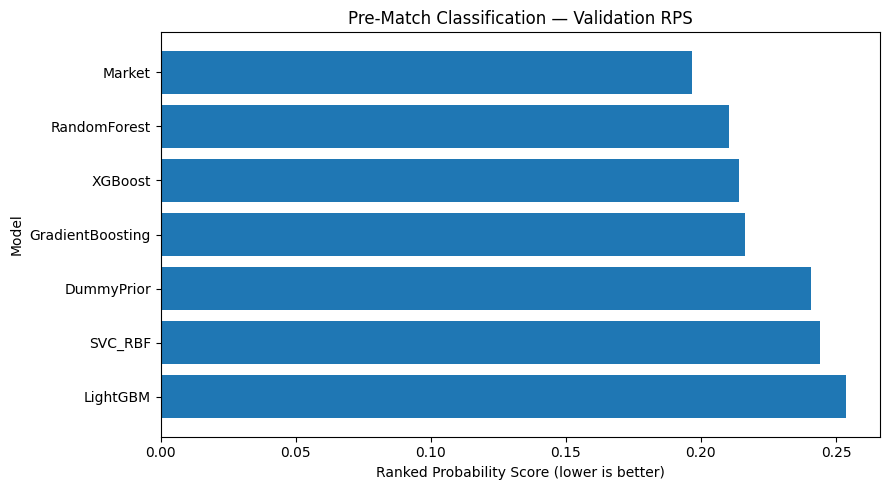

In [23]:
# -------------------------------------------------------------------------
# CLASSIFICATION VALIDATION RPS PLOT
# -------------------------------------------------------------------------

classification_plot_df = (
    classification_calibration_results_df
    .sort_values(
        "rps",
        ascending=False,
    )
)


plt.figure(
    figsize=(
        9,
        5,
    )
)

plt.barh(
    classification_plot_df[
        "model"
    ],
    classification_plot_df[
        "rps"
    ],
)

plt.xlabel(
    "Ranked Probability Score (lower is better)"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Pre-Match Classification — Validation RPS"
)

plt.tight_layout()

plt.show()

In [24]:
# -------------------------------------------------------------------------
# CLIPPED REGRESSION SCORER
# -------------------------------------------------------------------------

MARGIN_LOWER_BOUND = -5.0
MARGIN_UPPER_BOUND = 5.0


def clip_margin_predictions(
    predictions,
):
    return np.clip(
        np.asarray(
            predictions,
            dtype=float,
        ),
        MARGIN_LOWER_BOUND,
        MARGIN_UPPER_BOUND,
    )


def negative_clipped_mae_scorer(
    estimator,
    X,
    y,
):
    predictions = (
        estimator.predict(
            X
        )
    )

    predictions = (
        clip_margin_predictions(
            predictions
        )
    )

    return -mean_absolute_error(
        y,
        predictions,
    )


print(
    "Clipped-MAE regression scorer configured."
)

Clipped-MAE regression scorer configured.


In [25]:
# -------------------------------------------------------------------------
# REGRESSION TEMPORAL MODEL SELECTION
# -------------------------------------------------------------------------

regression_search_results = {}
regression_best_estimators = {}
regression_cv_records = []


for model_name, specification in (
    regression_specs.items()
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Regression search: {model_name}"
    )

    print(
        "=" * 72
    )


    result = run_temporal_grid_search(
        model_name=model_name,
        estimator=specification[
            "estimator"
        ],
        param_grid=specification[
            "param_grid"
        ],
        X=X_train,
        y=y_margin_train,
        scoring=negative_clipped_mae_scorer,
    )


    regression_search_results[
        model_name
    ] = result

    regression_best_estimators[
        model_name
    ] = result[
        "best_estimator"
    ]


    search_object = result[
        "search_object"
    ]

    best_index = (
        search_object.best_index_
    )


    best_cv_mae = -float(
        search_object.best_score_
    )

    cv_mae_std = float(
        search_object.cv_results_[
            "std_test_score"
        ][
            best_index
        ]
    )


    regression_cv_records.append(
        {
            "model": model_name,
            "search_configurations": (
                result[
                    "search_configurations"
                ]
            ),
            "cv_mean_mae": best_cv_mae,
            "cv_std_mae": cv_mae_std,
            "fit_seconds": (
                result[
                    "fit_seconds"
                ]
            ),
            "best_params": json.dumps(
                result[
                    "best_params"
                ],
                sort_keys=True,
            ),
        }
    )


    model_output_path = (
        BASELINE_MODEL_DIR
        / (
            "regression_"
            f"{model_name.lower()}_"
            "selection_fit.joblib"
        )
    )


    joblib.dump(
        result[
            "best_estimator"
        ],
        model_output_path,
    )


    print(
        f"Best temporal-CV MAE: "
        f"{best_cv_mae:.4f}"
    )

    print(
        "Best parameters:"
    )

    print(
        result[
            "best_params"
        ]
    )


regression_cv_results_df = (
    pd.DataFrame(
        regression_cv_records
    )
    .sort_values(
        "cv_mean_mae",
        ascending=True,
    )
    .reset_index(drop=True)
)


regression_cv_results_df.to_csv(
    REGRESSION_CV_RESULTS_PATH,
    index=False,
)


print(
    "\nRegression temporal model selection complete."
)

display(
    regression_cv_results_df
)


Regression search: SVR_RBF
Best temporal-CV MAE: 1.4176
Best parameters:
{'model__C': 0.25, 'model__gamma': 'scale'}

Regression search: KernelRidge_RBF
Best temporal-CV MAE: 1.4610
Best parameters:
{'model__alpha': 10.0, 'model__gamma': 0.01}

Regression search: Nystroem_Ridge
Best temporal-CV MAE: 1.4461
Best parameters:
{'kernel__gamma': 0.01, 'kernel__n_components': 25, 'model__alpha': 1.0}

Regression search: RandomForest


/home/sina/anaconda3/lib/python3.11/site-packages/sklearn/kernel_approximation.py:1001: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/home/sina/anaconda3/lib/python3.11/site-packages/sklearn/kernel_approximation.py:1001: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/home/sina/anaconda3/lib/python3.11/site-packages/sklearn/kernel_approximation.py:1001: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/home/sina/anaconda3/lib/python3.11/site-packages/sklearn/kernel_approximation.py:1001: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient eval

Best temporal-CV MAE: 1.3644
Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5}

Regression search: GradientBoosting
Best temporal-CV MAE: 1.3765
Best parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 1, 'model__n_estimators': 100}

Regression search: XGBoost
Best temporal-CV MAE: 1.4115
Best parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__subsample': 1.0}

Regression search: LightGBM
Best temporal-CV MAE: 1.4270
Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__num_leaves': 7}

Regression temporal model selection complete.


,model,search_configurations,cv_mean_mae,cv_std_mae,fit_seconds,best_params
0,RandomForest,8,1.3644,0.0970,2.7679,"{""model__max_depth"": null, ""model__max_feature..."
1,GradientBoosting,8,1.3765,0.0806,1.6756,"{""model__learning_rate"": 0.03, ""model__max_dep..."
2,XGBoost,8,1.4115,0.1565,3.1693,"{""model__learning_rate"": 0.03, ""model__max_dep..."
3,SVR_RBF,8,1.4176,0.0838,0.1500,"{""model__C"": 0.25, ""model__gamma"": ""scale""}"
4,LightGBM,8,1.4270,0.0853,0.5146,"{""model__colsample_bytree"": 1.0, ""model__learn..."
5,Nystroem_Ridge,8,1.4461,0.0690,0.1100,"{""kernel__gamma"": 0.01, ""kernel__n_components""..."
6,KernelRidge_RBF,8,1.4610,0.0652,0.0947,"{""model__alpha"": 10.0, ""model__gamma"": 0.01}"


In [26]:
# -------------------------------------------------------------------------
# REGRESSION VALIDATION EVALUATION
# -------------------------------------------------------------------------

regression_calibration_records = []

regression_prediction_store = {}


# -------------------------------------------------------------------------
# 1. DUMMY MEAN-MARGIN BASELINE
# -------------------------------------------------------------------------

dummy_regressor = DummyRegressor(
    strategy="mean"
)


dummy_regressor.fit(
    np.zeros(
        (
            len(
                y_margin_train
            ),
            1,
        )
    ),
    y_margin_train,
)


dummy_margin_predictions = (
    dummy_regressor.predict(
        np.zeros(
            (
                len(
                    y_margin_calibration
                ),
                1,
            )
        )
    )
)


dummy_margin_predictions = (
    clip_margin_predictions(
        dummy_margin_predictions
    )
)


regression_prediction_store[
    "DummyMean"
] = (
    dummy_margin_predictions
)


dummy_regression_metrics = (
    evaluate_regression_predictions(
        y_margin_calibration,
        dummy_margin_predictions,
    )
)


regression_calibration_records.append(
    {
        "model": "DummyMean",
        "model_type": "reference",
        **dummy_regression_metrics,
    }
)


# -------------------------------------------------------------------------
# 2. TUNED REGRESSION MODELS
# -------------------------------------------------------------------------

for model_name, estimator in (
    regression_best_estimators.items()
):

    predictions = (
        estimator.predict(
            X_calibration
        )
    )


    predictions = (
        clip_margin_predictions(
            predictions
        )
    )


    regression_prediction_store[
        model_name
    ] = predictions


    metrics = (
        evaluate_regression_predictions(
            y_margin_calibration,
            predictions,
        )
    )


    regression_calibration_records.append(
        {
            "model": model_name,
            "model_type": "tuned_ml",
            **metrics,
        }
    )


regression_calibration_results_df = (
    pd.DataFrame(
        regression_calibration_records
    )
    .sort_values(
        "mae",
        ascending=True,
    )
    .reset_index(drop=True)
)


regression_calibration_results_df.to_csv(
    REGRESSION_CALIBRATION_RESULTS_PATH,
    index=False,
)


print(
    "Regression validation evaluation complete."
)

display(
    regression_calibration_results_df
)

Regression validation evaluation complete.


,model,model_type,mae,rmse,correlation
0,RandomForest,tuned_ml,1.3583,1.6879,0.5355
1,LightGBM,tuned_ml,1.4080,1.7540,0.4505
2,GradientBoosting,tuned_ml,1.4108,1.7644,0.4762
3,XGBoost,tuned_ml,1.4397,1.7373,0.4657
4,KernelRidge_RBF,tuned_ml,1.4439,1.8506,0.4846
5,SVR_RBF,tuned_ml,1.4448,1.8128,0.5017
6,Nystroem_Ridge,tuned_ml,1.4858,1.8835,0.3667
7,DummyMean,reference,1.5708,1.9754,0.0000


In [27]:
# -------------------------------------------------------------------------
# REGRESSION VALIDATION PREDICTIONS
# -------------------------------------------------------------------------

regression_calibration_predictions_df = (
    calibration_df[
        [
            "match_id",
            "clean_date",
            "home_team",
            "away_team",
            "target_margin",
        ]
    ]
    .copy()
)


for model_name, predictions in (
    regression_prediction_store.items()
):

    regression_calibration_predictions_df[
        f"{model_name}_prediction"
    ] = predictions


regression_calibration_predictions_df.to_csv(
    REGRESSION_CALIBRATION_PREDICTIONS_PATH,
    index=False,
)


print(
    "Regression validation predictions saved."
)

print(
    f"Rows: "
    f"{len(regression_calibration_predictions_df):,}"
)

Regression validation predictions saved.
Rows: 61


In [28]:
# -------------------------------------------------------------------------
# SELECT REGRESSION MODEL FAMILY
# -------------------------------------------------------------------------

tuned_regression_results_df = (
    regression_calibration_results_df.loc[
        regression_calibration_results_df[
            "model_type"
        ].eq(
            "tuned_ml"
        )
    ]
    .sort_values(
        "mae",
        ascending=True,
    )
    .reset_index(drop=True)
)


SELECTED_REGRESSOR_NAME = (
    tuned_regression_results_df.iloc[
        0
    ][
        "model"
    ]
)


SELECTED_REGRESSOR_PARAMS = (
    regression_search_results[
        SELECTED_REGRESSOR_NAME
    ][
        "best_params"
    ]
)


selected_regressor_metrics = (
    tuned_regression_results_df.iloc[
        0
    ]
)


print(
    "Selected regression baseline:"
)

print(
    SELECTED_REGRESSOR_NAME
)

print(
    "\nLocked hyperparameters:"
)

print(
    SELECTED_REGRESSOR_PARAMS
)

print(
    "\nValidation metrics:"
)

display(
    selected_regressor_metrics
    .to_frame(
        name="value"
    )
)

Selected regression baseline:
RandomForest

Locked hyperparameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5}

Validation metrics:


,value
model,RandomForest
model_type,tuned_ml
mae,1.3583
rmse,1.6879
correlation,0.5355


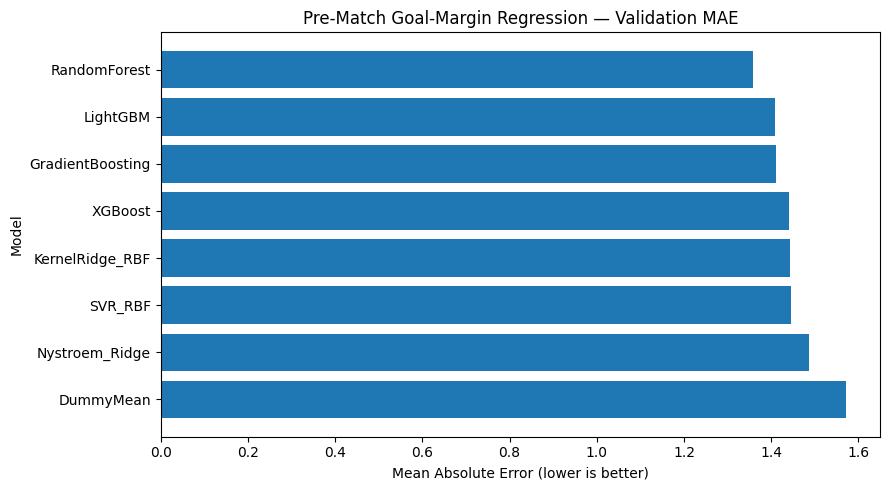

In [29]:
# -------------------------------------------------------------------------
# REGRESSION VALIDATION MAE PLOT
# -------------------------------------------------------------------------

regression_plot_df = (
    regression_calibration_results_df
    .sort_values(
        "mae",
        ascending=False,
    )
)


plt.figure(
    figsize=(
        9,
        5,
    )
)

plt.barh(
    regression_plot_df[
        "model"
    ],
    regression_plot_df[
        "mae"
    ],
)

plt.xlabel(
    "Mean Absolute Error (lower is better)"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Pre-Match Goal-Margin Regression — Validation MAE"
)

plt.tight_layout()

plt.show()

In [30]:
# -------------------------------------------------------------------------
# FREEZE BASELINE MODEL SELECTION
# -------------------------------------------------------------------------

baseline_selection_manifest = {
    "classification": {
        "selected_model": (
            SELECTED_CLASSIFIER_NAME
        ),
        "selection_metric": (
            "validation_rps"
        ),
        "best_params": (
            SELECTED_CLASSIFIER_PARAMS
        ),
        "validation_rps": float(
            selected_classifier_metrics[
                "rps"
            ]
        ),
        "validation_log_loss": float(
            selected_classifier_metrics[
                "log_loss"
            ]
        ),
        "validation_brier": float(
            selected_classifier_metrics[
                "brier"
            ]
        ),
        "validation_ece": float(
            selected_classifier_metrics[
                "ece"
            ]
        ),
    },

    "regression": {
        "selected_model": (
            SELECTED_REGRESSOR_NAME
        ),
        "selection_metric": (
            "validation_mae"
        ),
        "best_params": (
            SELECTED_REGRESSOR_PARAMS
        ),
        "validation_mae": float(
            selected_regressor_metrics[
                "mae"
            ]
        ),
        "validation_rmse": float(
            selected_regressor_metrics[
                "rmse"
            ]
        ),
        "validation_correlation": float(
            selected_regressor_metrics[
                "correlation"
            ]
        ),
    },

    "development_protocol": {
        "model_selection_matches": int(
            len(
                training_df
            )
        ),
        "validation_matches": int(
            len(
                calibration_df
            )
        ),
        "sealed_test_matches": int(
            len(
                sealed_test_df
            )
        ),
        "temporal_cv_splits": int(
            N_TEMPORAL_CV_SPLITS
        ),
        "search_budget_per_model": int(
            SEARCH_BUDGET
        ),
    },

    "features": {
        "combined_predictors": int(
            len(
                FULL_FEATURE_COLUMNS
            )
        ),
        "conventional_predictors": int(
            len(
                CONVENTIONAL_FEATURE_COLUMNS
            )
        ),
        "network_predictors": int(
            len(
                NETWORK_FEATURE_COLUMNS
            )
        ),
    },

    "test_set_opened": False,
}


with open(
    BASELINE_SELECTION_PATH,
    "w",
    encoding="utf-8",
) as file_handle:

    json.dump(
        baseline_selection_manifest,
        file_handle,
        indent=4,
    )


# -------------------------------------------------------------------------
# UPDATE ORIGINAL EXPERIMENT CONFIGURATION
# -------------------------------------------------------------------------

experiment_config[
    "selected_classifier"
] = SELECTED_CLASSIFIER_NAME

experiment_config[
    "selected_regressor"
] = SELECTED_REGRESSOR_NAME

experiment_config[
    "test_set_opened"
] = False


with open(
    EXPERIMENT_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file_handle:

    json.dump(
        experiment_config,
        file_handle,
        indent=4,
    )


print(
    "Notebook 06 baseline selections frozen."
)

print(
    f"Classifier: {SELECTED_CLASSIFIER_NAME}"
)

print(
    f"Regressor : {SELECTED_REGRESSOR_NAME}"
)

print(
    "Held-out test status: SEALED"
)

Notebook 06 baseline selections frozen.
Classifier: RandomForest
Regressor : RandomForest
Held-out test status: SEALED


In [31]:
# -------------------------------------------------------------------------
# NOTEBOOK 06 FINAL VALIDATION
# -------------------------------------------------------------------------

reloaded_classification_cv_df = (
    pd.read_csv(
        CLASSIFICATION_CV_RESULTS_PATH
    )
)

reloaded_regression_cv_df = (
    pd.read_csv(
        REGRESSION_CV_RESULTS_PATH
    )
)

reloaded_classification_validation_df = (
    pd.read_csv(
        CALIBRATION_RESULTS_PATH
    )
)

reloaded_regression_validation_df = (
    pd.read_csv(
        REGRESSION_CALIBRATION_RESULTS_PATH
    )
)


with open(
    BASELINE_SELECTION_PATH,
    "r",
    encoding="utf-8",
) as file_handle:

    reloaded_selection_manifest = (
        json.load(
            file_handle
        )
    )


# -------------------------------------------------------------------------
# EXPECTED RESULT COUNTS
# -------------------------------------------------------------------------

assert len(
    reloaded_classification_cv_df
) == 5

assert len(
    reloaded_regression_cv_df
) == 7

assert len(
    reloaded_classification_validation_df
) == 7
# Dummy + Market + 5 tuned models

assert len(
    reloaded_regression_validation_df
) == 8
# Dummy + 7 tuned models


# -------------------------------------------------------------------------
# LOCKED MODEL VALIDATION
# -------------------------------------------------------------------------

assert (
    reloaded_selection_manifest[
        "classification"
    ][
        "selected_model"
    ]
    in classification_specs
)

assert (
    reloaded_selection_manifest[
        "regression"
    ][
        "selected_model"
    ]
    in regression_specs
)


# -------------------------------------------------------------------------
# TEST LEAKAGE VALIDATION
# -------------------------------------------------------------------------

assert (
    reloaded_selection_manifest[
        "test_set_opened"
    ]
    is False
)

assert "X_test" not in globals()
assert "y_class_test" not in globals()
assert "y_margin_test" not in globals()


# -------------------------------------------------------------------------
# MODEL ARTIFACT VALIDATION
# -------------------------------------------------------------------------

for model_name in (
    classification_specs.keys()
):

    artifact_path = (
        BASELINE_MODEL_DIR
        / (
            "classification_"
            f"{model_name.lower()}_"
            "selection_fit.joblib"
        )
    )

    assert artifact_path.exists()


for model_name in (
    regression_specs.keys()
):

    artifact_path = (
        BASELINE_MODEL_DIR
        / (
            "regression_"
            f"{model_name.lower()}_"
            "selection_fit.joblib"
        )
    )

    assert artifact_path.exists()


print(
    "Notebook 06 final validation passed."
)

print(
    f"Classification models tuned : "
    f"{len(reloaded_classification_cv_df)}"
)

print(
    f"Regression models tuned     : "
    f"{len(reloaded_regression_cv_df)}"
)

print(
    f"Selected classifier         : "
    f"{SELECTED_CLASSIFIER_NAME}"
)

print(
    f"Selected regressor          : "
    f"{SELECTED_REGRESSOR_NAME}"
)

print(
    f"Held-out test matches       : "
    f"{len(sealed_test_df)}"
)

print(
    "Held-out test opened       : False"
)

Notebook 06 final validation passed.
Classification models tuned : 5
Regression models tuned     : 7
Selected classifier         : RandomForest
Selected regressor          : RandomForest
Held-out test matches       : 79
Held-out test opened       : False


# Notebook 06 Summary — Baseline Models and Experimental Protocol

## Experimental design

The baseline-model experiment uses a strictly chronological development and
held-out evaluation design.

The season is divided into:

- a historical model-selection period;
- a later validation period;
- a final sealed held-out test period.

Within the model-selection period, hyperparameters are chosen using expanding,
date-blocked temporal cross-validation.

No fixture date can occur on both sides of a training/validation fold.

All imputation and scaling operations are contained inside model pipelines and
are therefore fitted only from the historical training portion of each fold.

---

## Classification

The following probabilistic classifiers were tuned:

```text
RBF SVC
Random Forest
Gradient Boosting
XGBoost
LightGBM